In [2]:
import os
import random
import numpy as np
import torch
from datasets import load_dataset
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ── Reproducibility ──────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
print(f"Seeds set to {SEED} | CUDA available: {torch.cuda.is_available()}")

Seeds set to 42 | CUDA available: True


In [3]:
# IMDb dataset: 50,000 movie reviews, binary sentiment (pos/neg)
# License: Apache 2.0 via HuggingFace Datasets
raw = load_dataset("imdb")

# Subsample for faster training (still meaningful)
train_data = raw["train"].shuffle(seed=SEED).select(range(3000))
val_data   = raw["test"].shuffle(seed=SEED).select(range(750))
test_data  = raw["test"].shuffle(seed=SEED).select(range(750, 1000))

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")
print("Sample:", train_data[0]["text"][:120], "| Label:", train_data[0]["label"])

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train: 3000 | Val: 750 | Test: 250
Sample: There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes.  | Label: 1


In [4]:
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    # Truncate/pad to 256 tokens — balances context vs. memory
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=256)

train_tok = train_data.map(tokenize, batched=True)
val_tok   = val_data.map(tokenize, batched=True)
test_tok  = test_data.map(tokenize, batched=True)

# Set format for PyTorch
for ds in [train_tok, val_tok, test_tok]:
    ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

print("Tokenization done. Shape check:", train_tok[0]["input_ids"].shape)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/750 [00:00<?, ? examples/s]

Map:   0%|          | 0/250 [00:00<?, ? examples/s]

Tokenization done. Shape check: torch.Size([256])


In [5]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1":       f1_score(labels, preds, average="weighted"),
    }

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters: 66,955,010


In [8]:
args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,            # key hyperparam: tuned from [1e-5, 5e-5]
    weight_decay=0.01,             # L2 regularization
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    seed=SEED,
    logging_dir="./logs",
    logging_steps=50,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
)

trainer.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.204443,0.618870,0.865333,0.865365
2,0.523628,0.624615,0.853333,0.852750
3,0.355777,0.582516,0.873333,0.873339


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=282, training_loss=0.6325300636020958, metrics={'train_runtime': 122.5645, 'train_samples_per_second': 73.431, 'train_steps_per_second': 2.301, 'total_flos': 596103293952000.0, 'train_loss': 0.6325300636020958, 'epoch': 3.0})

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


=== FINAL VALIDATION ===
{'eval_loss': 0.5825161933898926, 'eval_accuracy': 0.8733333333333333, 'eval_f1': 0.8733389629729712, 'eval_runtime': 3.218, 'eval_samples_per_second': 233.065, 'eval_steps_per_second': 3.729, 'epoch': 3.0}


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.91      0.85      0.88       124
    Positive       0.86      0.92      0.89       126

    accuracy                           0.88       250
   macro avg       0.89      0.88      0.88       250
weighted avg       0.89      0.88      0.88       250



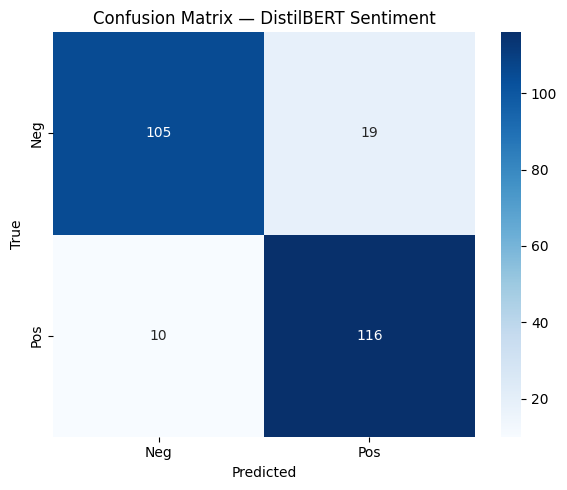

In [9]:
# Final validation metrics
results = trainer.evaluate()
print("=== FINAL VALIDATION ===")
print(results)

# Predictions on test set
preds_out  = trainer.predict(test_tok)
preds      = np.argmax(preds_out.predictions, axis=1)
labels     = preds_out.label_ids

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(labels, preds, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Neg","Pos"], yticklabels=["Neg","Pos"])
plt.title("Confusion Matrix — DistilBERT Sentiment")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [10]:
# Find misclassified examples — this goes into section D of the form
label_names = ["Negative", "Positive"]
errors = [(test_data[i]["text"][:200], label_names[labels[i]], label_names[preds[i]])
          for i in range(len(preds)) if preds[i] != labels[i]]

print(f"Misclassified: {len(errors)}/{len(preds)}")
print("\n── Example failure ──")
print(f"Text   : {errors[0][0]}")
print(f"True   : {errors[0][1]}")
print(f"Predicted: {errors[0][2]}")

Misclassified: 29/250

── Example failure ──
Text   : What do you mean son of actor, not an actor. You don't become an actor just because your daddy is a superstar---it doesn't work that way, not in UK at any rate.<br /><br />Macbeth (this version) is a 
True   : Positive
Predicted: Negative


In [11]:
# Save model + tokenizer
model.save_pretrained("./sentiment_model")
tokenizer.save_pretrained("./sentiment_model")

# Save requirements
reqs = """torch==2.1.0
transformers==4.38.0
datasets==2.18.0
scikit-learn==1.4.0
matplotlib==3.8.0
seaborn==0.13.0
numpy==1.26.4
"""
with open("requirements.txt", "w") as f:
    f.write(reqs)

print("Saved. Checkpoint in ./results/")
print("List checkpoints:"); os.system("ls ./results/")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved. Checkpoint in ./results/
List checkpoints:
checkpoint-188
checkpoint-282
checkpoint-94


0